# Statistical Distributions, Hypothesis Testing & Actionable Insights

---

## Setup: Import Libraries

In [ ]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import math
from scipy import stats
from scipy.stats import poisson,norm,chi2_contingency
sys.path.append("../src")
from data_loader import load_data
from statsmodels.stats.multicomp import pairwise_tukeyhsd
#from hypothesis_tests import ttest_ind, f_oneway, chi2_contingency, poisson, norm
from preprocessing import clean_insurance_data,get_group_statistics,perform_t_test,get_region_statistics,perform_anova


# Reproducibility
np.random.seed(42)

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Section 1: Generate the Dataset

In [ ]:

df = load_data(
    "../data/MachineLearningRating_v3.csv"
)

df.head()

Successfully loaded data from ../data/MachineLearningRating_v3.csv


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,1970-01-01 00:00:00.000042064,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,1970-01-01 00:00:00.000042125,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,1970-01-01 00:00:00.000042186,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,1970-01-01 00:00:00.000042125,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,1970-01-01 00:00:00.000042186,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [ ]:
# Quick summary statistics
df.describe().round(2)

,UnderwrittenCoverID,PolicyID,TransactionMonth,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,CapitalOutstanding,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1000098.00,1000098.00,1000098,1000098.00,973931.00,974483.00,973931.00,973931.00,973931.00,973931.00,973931.00,214985.00,974481.00,0.0,974163.00,974163.00,973382.00,973382.00
mean,104817.55,7956.68,1970-01-01 00:00:00.000042063,3020.60,54803836.56,2010.19,4.05,2467.56,97.31,4.02,39539.19,224537.00,52380.31,NaN,604676.84,117.62,61.74,65.58
min,1.00,14.00,1970-01-01 00:00:00.000041548,1.00,4041200.00,1987.00,0.00,0.00,0.00,0.00,28399.00,20000.00,-2.00,NaN,0.01,0.00,-782.58,-12002.41
25%,55143.00,4500.00,1970-01-01 00:00:00.000042005,827.00,60056925.00,2008.00,4.00,2237.00,75.00,4.00,39387.00,135000.00,0.00,NaN,5000.00,3.20,0.00,0.00
50%,94083.00,7071.00,1970-01-01 00:00:00.000042095,2000.00,60058415.00,2011.00,4.00,2694.00,111.00,4.00,40452.00,220000.00,0.00,NaN,7500.00,8.43,2.18,0.00
75%,139190.00,11077.00,1970-01-01 00:00:00.000042156,4180.00,60058418.00,2013.00,4.00,2694.00,111.00,4.00,41000.00,280000.00,0.00,NaN,250000.00,90.00,21.93,0.00
max,301175.00,23246.00,1970-01-01 00:00:00.000042217,9870.00,65065350.00,2015.00,10.00,12880.00,309.00,6.00,41883.00,26550000.00,700000.00,NaN,12636200.00,74422.17,65282.60,393092.11
std,63293.71,5290.04,NaN,2649.85,13696698.31,3.26,0.30,443.84,19.41,0.47,2015.34,571430.52,110977.60,NaN,1509245.86,403.10,231.72,2390.03


Original shape: (1000098, 52)
Processed shape: (963602, 52)


c:\Users\habtamu.amsalu\Downloads\insurance-risk-analytics\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


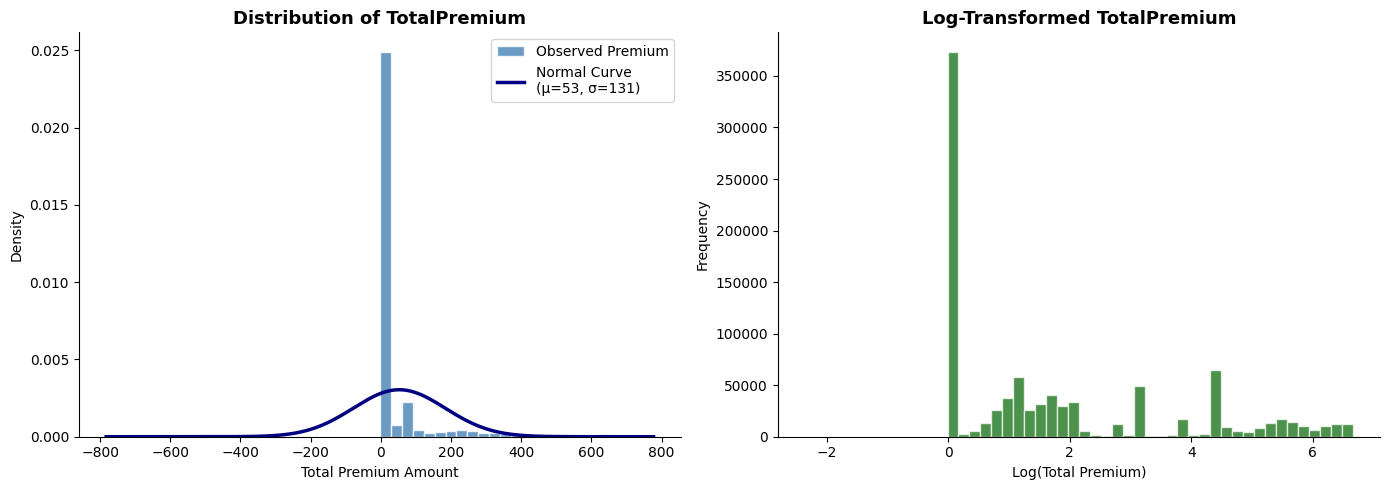

Mean Premium: 52.54
Skewness:     3.34 (Positive = Right Skewed)
Mean:   52.540
Median: 2.125
Std:    131.157
Skewness: 3.338  (close to 0 = symmetric)


In [ ]:
df_processed = clean_insurance_data(df)

# --- Analysis Cell ---
# Now you can proceed to plot using df_processed
print(f"Original shape: {df.shape}")
print(f"Processed shape: {df_processed.shape}")

# 2. Setup Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: Histogram of TotalPremium ---
ax = axes[0]
ax.hist(df_processed['TotalPremium'], bins=50, color='steelblue', edgecolor='white',
        alpha=0.8, density=True, label='Observed Premium')

# Overlay Normal Curve (using mean and std of the data)
mu, sigma = df_processed['TotalPremium'].mean(), df_processed['TotalPremium'].std()
# Create x-axis range based on the actual min/max of your data
x = np.linspace(df_processed['TotalPremium'].min(), df_processed['TotalPremium'].max(), 300)
ax.plot(x, norm.pdf(x, mu, sigma), color='navy', linewidth=2.5,
        label=f'Normal Curve\n(μ={mu:.0f}, σ={sigma:.0f})')

ax.set_title('Distribution of TotalPremium', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Premium Amount')
ax.set_ylabel('Density')
ax.legend()

# --- Right plot: Log-transformed Distribution ---
# Financial data often looks more "Normal" after a log transform
ax2 = axes[1]
log_premium = np.log1p(df_processed['TotalPremium']) # log(1+x) to handle zeros
ax2.hist(log_premium, bins=50, color='darkgreen', edgecolor='white', alpha=0.7)
ax2.set_title('Log-Transformed TotalPremium', fontsize=13, fontweight='bold')
ax2.set_xlabel('Log(Total Premium)')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Statistics
print(f'Mean Premium: {mu:.2f}')
print(f'Skewness:     {df_processed["TotalPremium"].skew():.2f} (Positive = Right Skewed)')
print(f'Mean:   {df_processed["TotalPremium"].mean():.3f}')
print(f'Median: {df_processed["TotalPremium"].median():.3f}')
print(f'Std:    {df_processed["TotalPremium"].std():.3f}')
print(f'Skewness: {df_processed["TotalPremium"].skew():.3f}  (close to 0 = symmetric)')

Original shape: (1000098, 52)
Processed shape: (963602, 52)


c:\Users\habtamu.amsalu\Downloads\insurance-risk-analytics\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


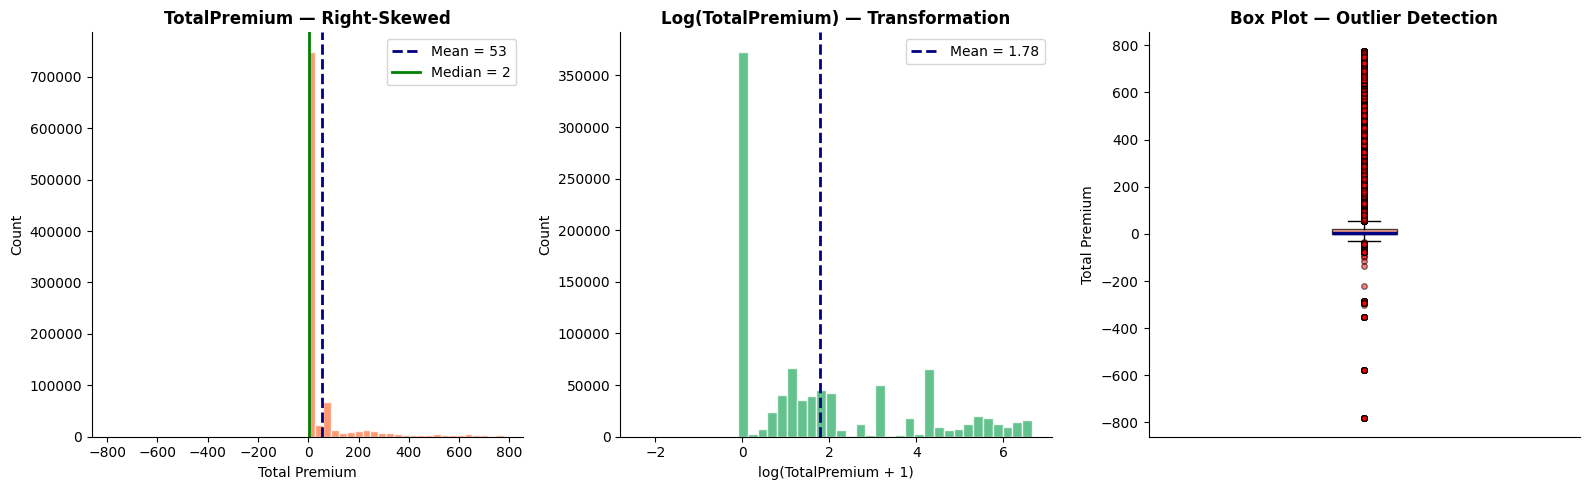

=== Key Statistics for TotalPremium ===
Mean:     52.54
Median:   2.12
Std Dev:  131.16
Skewness: 3.338 (Positive = Right Skewed)
Outliers (IQR method): 193365 policies (20.1%)
Largest single premium: 777.16


In [ ]:

print(f"Original shape: {df.shape}")
print(f"Processed shape: {df_processed.shape}")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Raw histogram showing the skew
ax = axes[0]
ax.hist(df_processed['TotalPremium'], bins=50, color='coral', edgecolor='white', alpha=0.8)
ax.axvline(df_processed['TotalPremium'].mean(), color='navy', linestyle='--', linewidth=2,
           label=f'Mean = {df_processed["TotalPremium"].mean():.0f}')
ax.axvline(df_processed['TotalPremium'].median(), color='green', linestyle='-', linewidth=2,
           label=f'Median = {df_processed["TotalPremium"].median():.0f}')
ax.set_title('TotalPremium — Right-Skewed', fontsize=12, fontweight='bold')
ax.set_xlabel('Total Premium')
ax.set_ylabel('Count')
ax.legend()

# 2. Log-transformed (helps check if it's log-normal)
ax2 = axes[1]
log_values = np.log1p(df_processed['TotalPremium']) # log1p handles potential zero values
ax2.hist(log_values, bins=40, color='mediumseagreen', edgecolor='white', alpha=0.8)
ax2.axvline(log_values.mean(), color='navy', linestyle='--', linewidth=2,
            label=f'Mean = {log_values.mean():.2f}')
ax2.set_title('Log(TotalPremium) — Transformation', fontsize=12, fontweight='bold')
ax2.set_xlabel('log(TotalPremium + 1)')
ax2.set_ylabel('Count')
ax2.legend()

# 3. Box plot showing outliers
ax3 = axes[2]
ax3.boxplot(df_processed['TotalPremium'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='coral', alpha=0.7),
            medianprops=dict(color='navy', linewidth=2.5),
            flierprops=dict(marker='o', markerfacecolor='red',
                            markersize=4, alpha=0.5))
ax3.set_title('Box Plot — Outlier Detection', fontsize=12, fontweight='bold')
ax3.set_ylabel('Total Premium')
ax3.set_xticks([])

plt.tight_layout()
plt.show()

# --- Statistical Printout ---
print('=== Key Statistics for TotalPremium ===')
print(f'Mean:     {df_processed["TotalPremium"].mean():.2f}')
print(f'Median:   {df_processed["TotalPremium"].median():.2f}')
print(f'Std Dev:  {df_processed["TotalPremium"].std():.2f}')
print(f'Skewness: {df_processed["TotalPremium"].skew():.3f} (Positive = Right Skewed)')

q1 = df_processed['TotalPremium'].quantile(0.25)
q3 = df_processed['TotalPremium'].quantile(0.75)
iqr = q3 - q1
outliers = df_processed[df_processed['TotalPremium'] > q3 + 1.5 * iqr]
print(f'Outliers (IQR method): {len(outliers)} policies ({len(outliers)/len(df_processed)*100:.1f}%)')
print(f'Largest single premium: {df_processed["TotalPremium"].max():.2f}')

### Interpretation of TotalPremium Distribution

#### Statistical Interpretation:

1.  **Right Skewness:** The histograms clearly show that `TotalPremium` is heavily right-skewed, meaning most policies have a low premium, but a long tail of policies have significantly higher premiums. The skewness value of **3.338** confirms this strong positive skew.
2.  **Mean vs. Median:** The mean premium (52.54) is considerably higher than the median premium (2.12), which is characteristic of right-skewed distributions and indicates the influence of high-value outliers pulling the mean upwards.
3.  **Outliers:** The box plot visually confirms the presence of numerous outliers, representing policies with exceptionally high premiums. Statistically, **20.1%** of policies are identified as outliers by the IQR method, with the largest single premium being **777.16**.
4.  **Log Transformation:** The log-transformed histogram shows a distribution that is much closer to a normal (bell-shaped) distribution. This suggests that a log transformation might be beneficial for modeling purposes, as many statistical models assume normally distributed residuals.

#### Practical Interpretation:

*   **Risk and Revenue Concentration:** The distribution highlights that a significant portion of the total premium comes from a relatively small number of high-value policies. This concentration of risk/revenue could have implications for portfolio management and pricing strategies.
*   **Outlier Management:** The high percentage of outliers suggests that these high-premium policies are not just rare anomalies but a significant segment of the data. Understanding the characteristics of these outliers could be crucial for accurate pricing and risk assessment.
*   **Modeling Implications:** For any predictive modeling of `TotalPremium`, the strong skewness and presence of outliers necessitate careful consideration. A log transformation or using models robust to non-normal distributions (e.g., Generalized Linear Models with a Gamma distribution) would likely improve model performance and interpretability.

---
### 2.3 Poisson Distribution


Original shape: (1000098, 52)
Processed shape: (963602, 52)


C:\Users\habtamu.amsalu\AppData\Local\Temp\ipykernel_22688\2961103224.py:68: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\habtamu.amsalu\Downloads\insurance-risk-analytics\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


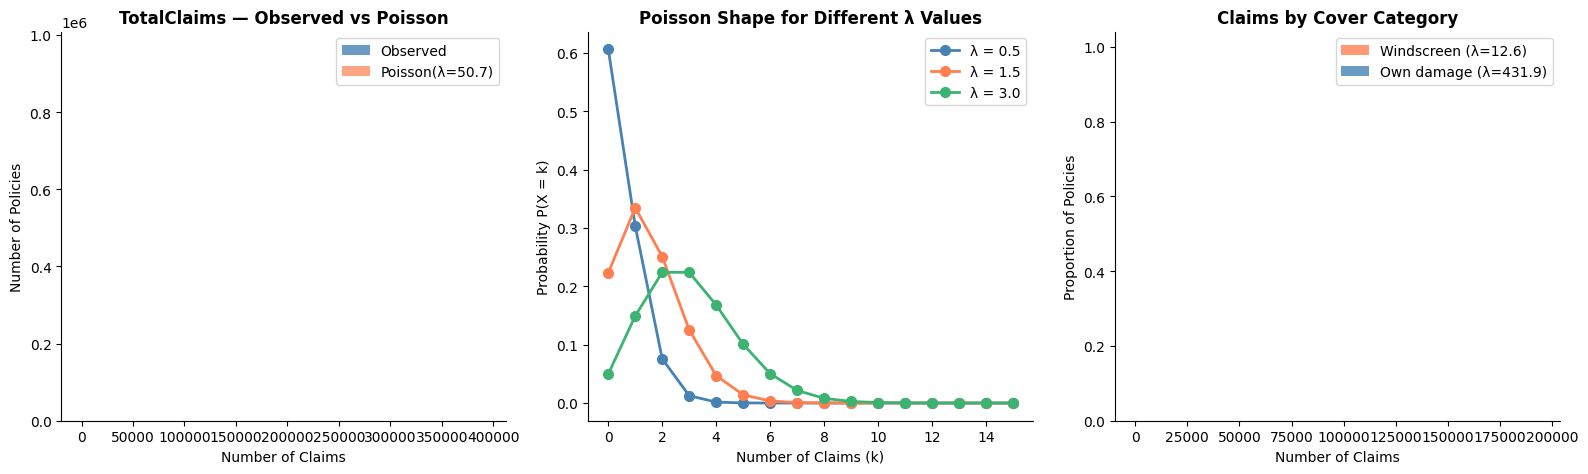

=== Poisson Statistics for TotalClaims ===
Overall λ (mean):    50.67
Overall variance:    3619277.55
Note: If Variance > Mean, the data is "Overdispersed" (Common in Insurance).


In [ ]:

print(f"Original shape: {df.shape}")
print(f"Processed shape: {df_processed.shape}")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Observed vs Theoretical Poisson
ax = axes[0]
lambda_obs = df_processed['TotalClaims'].mean()
max_k = int(df_processed['TotalClaims'].max())
k_values = np.arange(0, max_k + 1)

observed_counts = df_processed['TotalClaims'].value_counts().sort_index()
theoretical_probs = poisson.pmf(k_values, mu=lambda_obs)
theoretical_counts = theoretical_probs * len(df_processed)

ax.bar(k_values - 0.2,[observed_counts.get(k, 0) for k in k_values],
       width=0.4, color='steelblue', alpha=0.8, label='Observed')
ax.bar(k_values + 0.2, theoretical_counts,
       width=0.4, color='coral', alpha=0.7, label=f'Poisson(λ={lambda_obs:.1f})')
ax.set_title('TotalClaims — Observed vs Poisson', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Claims')
ax.set_ylabel('Number of Policies')
ax.legend()

# 2. Poisson Shape for Different λ
ax2 = axes[1]
k_range = np.arange(0, 16)
for lam, color in[(0.5, 'steelblue'), (1.5, 'coral'), (3.0, 'mediumseagreen')]:
    probs = poisson.pmf(k_range, mu=lam)
    ax2.plot(k_range, probs, 'o-', color=color, linewidth=2, markersize=7, label=f'λ = {lam}')
ax2.set_title('Poisson Shape for Different λ Values', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Claims (k)')
ax2.set_ylabel('Probability P(X = k)')
ax2.legend()

# 3. Claims by CoverCategory (Comparison)
ax3 = axes[2]
# Using 'CoverCategory' as a proxy for groups (Check your dataframe for other categorical columns)
groups = df_processed['CoverCategory'].unique()
if len(groups) >= 2:
    g1, g2 = groups[0], groups[1]
    data1 = df_processed[df_processed['CoverCategory'] == g1]['TotalClaims']
    data2 = df_processed[df_processed['CoverCategory'] == g2]['TotalClaims']

    max_k2 = int(max(data1.max(), data2.max()))
    k2 = np.arange(0, max_k2 + 1)

    # Calculate proportions
    counts1 =[sum(data1 == k) / len(data1) for k in k2]
    counts2 =[sum(data2 == k) / len(data2) for k in k2]

    ax3.bar(k2 - 0.2, counts1, width=0.4, color='coral', alpha=0.8, label=f'{g1} (λ={data1.mean():.1f})')
    ax3.bar(k2 + 0.2, counts2, width=0.4, color='steelblue', alpha=0.8, label=f'{g2} (λ={data2.mean():.1f})')
    ax3.set_title('Claims by Cover Category', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Number of Claims')
    ax3.set_ylabel('Proportion of Policies')
    ax3.legend()

plt.tight_layout()
plt.show()

# --- Statistics ---
print('=== Poisson Statistics for TotalClaims ===')
print(f'Overall λ (mean):    {df_processed["TotalClaims"].mean():.2f}')
print(f'Overall variance:    {df_processed["TotalClaims"].var():.2f}')
print(f'Note: If Variance > Mean, the data is "Overdispersed" (Common in Insurance).')

### Interpretation of TotalClaims Distribution (Poisson)

#### Statistical Interpretation:

1.  **Observed vs. Poisson Model (Overall):** The first plot compares the observed distribution of `TotalClaims` to a theoretical Poisson distribution with λ (mean) = 50.67. The observed data significantly deviates from the theoretical Poisson distribution. Specifically, the observed data shows a much higher frequency of policies with 0 claims and a much longer, less smooth tail of higher claim counts than the theoretical Poisson would predict.
2.  **Overdispersion:** The key finding from the statistics is that the overall mean of `TotalClaims` is **50.67**, while the variance is a significantly larger **3,619,277.55**. This indicates severe **overdispersion** (variance >> mean), a common phenomenon in insurance claims data. This violates a core assumption of the basic Poisson model, meaning a simple Poisson model would be inadequate for this data.
3.  **Poisson Shape for Different λ Values:** The second plot illustrates how the Poisson distribution changes with different λ values. As λ increases, the distribution shifts to the right and becomes more symmetric, approaching a normal distribution. This helps to understand that for our large observed λ, we would expect a more bell-shaped distribution, which we don't see in the observed data, further emphasizing the overdispersion.
4.  **Claims by CoverCategory Comparison:** The third plot compares the claim proportions for two `CoverCategory` groups. It shows distinct differences in the distribution and average claim counts (λ values) between categories. This suggests that `CoverCategory` is a significant factor influencing claim frequency.

#### Practical Interpretation:

*   **Beyond Simple Poisson:** Due to the severe overdispersion, a standard Poisson regression model would not be appropriate for modeling `TotalClaims`. Actuaries and data scientists should consider alternative models such as **Negative Binomial regression** or **Zero-Inflated Poisson/Negative Binomial models**, which are designed to handle overdispersion and excess zeros often found in insurance claims data.
*   **Heterogeneity in Claims:** The overdispersion implies that the underlying rate of claims (λ) is not constant across all policies or policyholders. There is significant heterogeneity, where some policies have a much higher propensity for claims than others.
*   **Category-Specific Risk:** The differences in claim patterns between `CoverCategory` groups highlight the importance of segmenting the portfolio. Different `CoverCategory` policies exhibit different claim behaviors, which must be accounted for in pricing and risk management. This validates the need for category-specific risk assessment rather than a blanket approach.

---
## Section 3: Hypothesis Testing


In [ ]:

group_col = 'CoverCategory'
target_col = 'TotalPremium'

# Get stats using our new src function
stats = get_group_statistics(df_processed, group_col, target_col)

print(f'=== Group Sizes ({group_col}) ===')
for group, data in stats.items():
    print(f'{group}: {data["count"]:,}')

print('\n=== Descriptive Statistics (TotalPremium) ===')
for group, data in stats.items():
    print(f'{group} — Mean: {data["mean"]:.2f}, Median: {data["median"]:.2f}, Std: {data["std"]:.2f}')

=== Group Sizes (CoverCategory) ===
Windscreen: 94,923
Own damage: 4,681
Third Party: 41,403
Passenger Liability: 100,674
Signage and Vehicle Wraps: 99,862
Keys and Alarms: 99,869
Cleaning and Removal of Accident Debris: 99,854
Emergency Charges: 99,856
Roadside Assistance: 3,834
Credit Protection: 7,842
Accidental Death: 25,918
Income Protector: 24,462
Basic Excess Waiver: 21,744
Own Damage : 28,177
Basic Excess Waiver (2015): 988
Windscreen (2015): 6,304
Income Protector (2015): 1,196
Deposit Cover: 683
Own Damage.: 5,696
Standalone passenger liability: 530
Baggage/Luggage: 150
Asset Value Preserver: 740
Cash Takings: 291
Factory Fitted Sound and Other Electronic Equipment: 3
Vehicle over R100 000: 393
Trailer: 36

=== Descriptive Statistics (TotalPremium) ===
Windscreen — Mean: 12.16, Median: 15.79, Std: 10.22
Own damage — Mean: 0.27, Median: 0.00, Std: 3.02
Third Party — Mean: 2.62, Median: 0.00, Std: 10.03
Passenger Liability — Mean: 1.05, Median: 1.10, Std: 1.03
Signage and Vehic

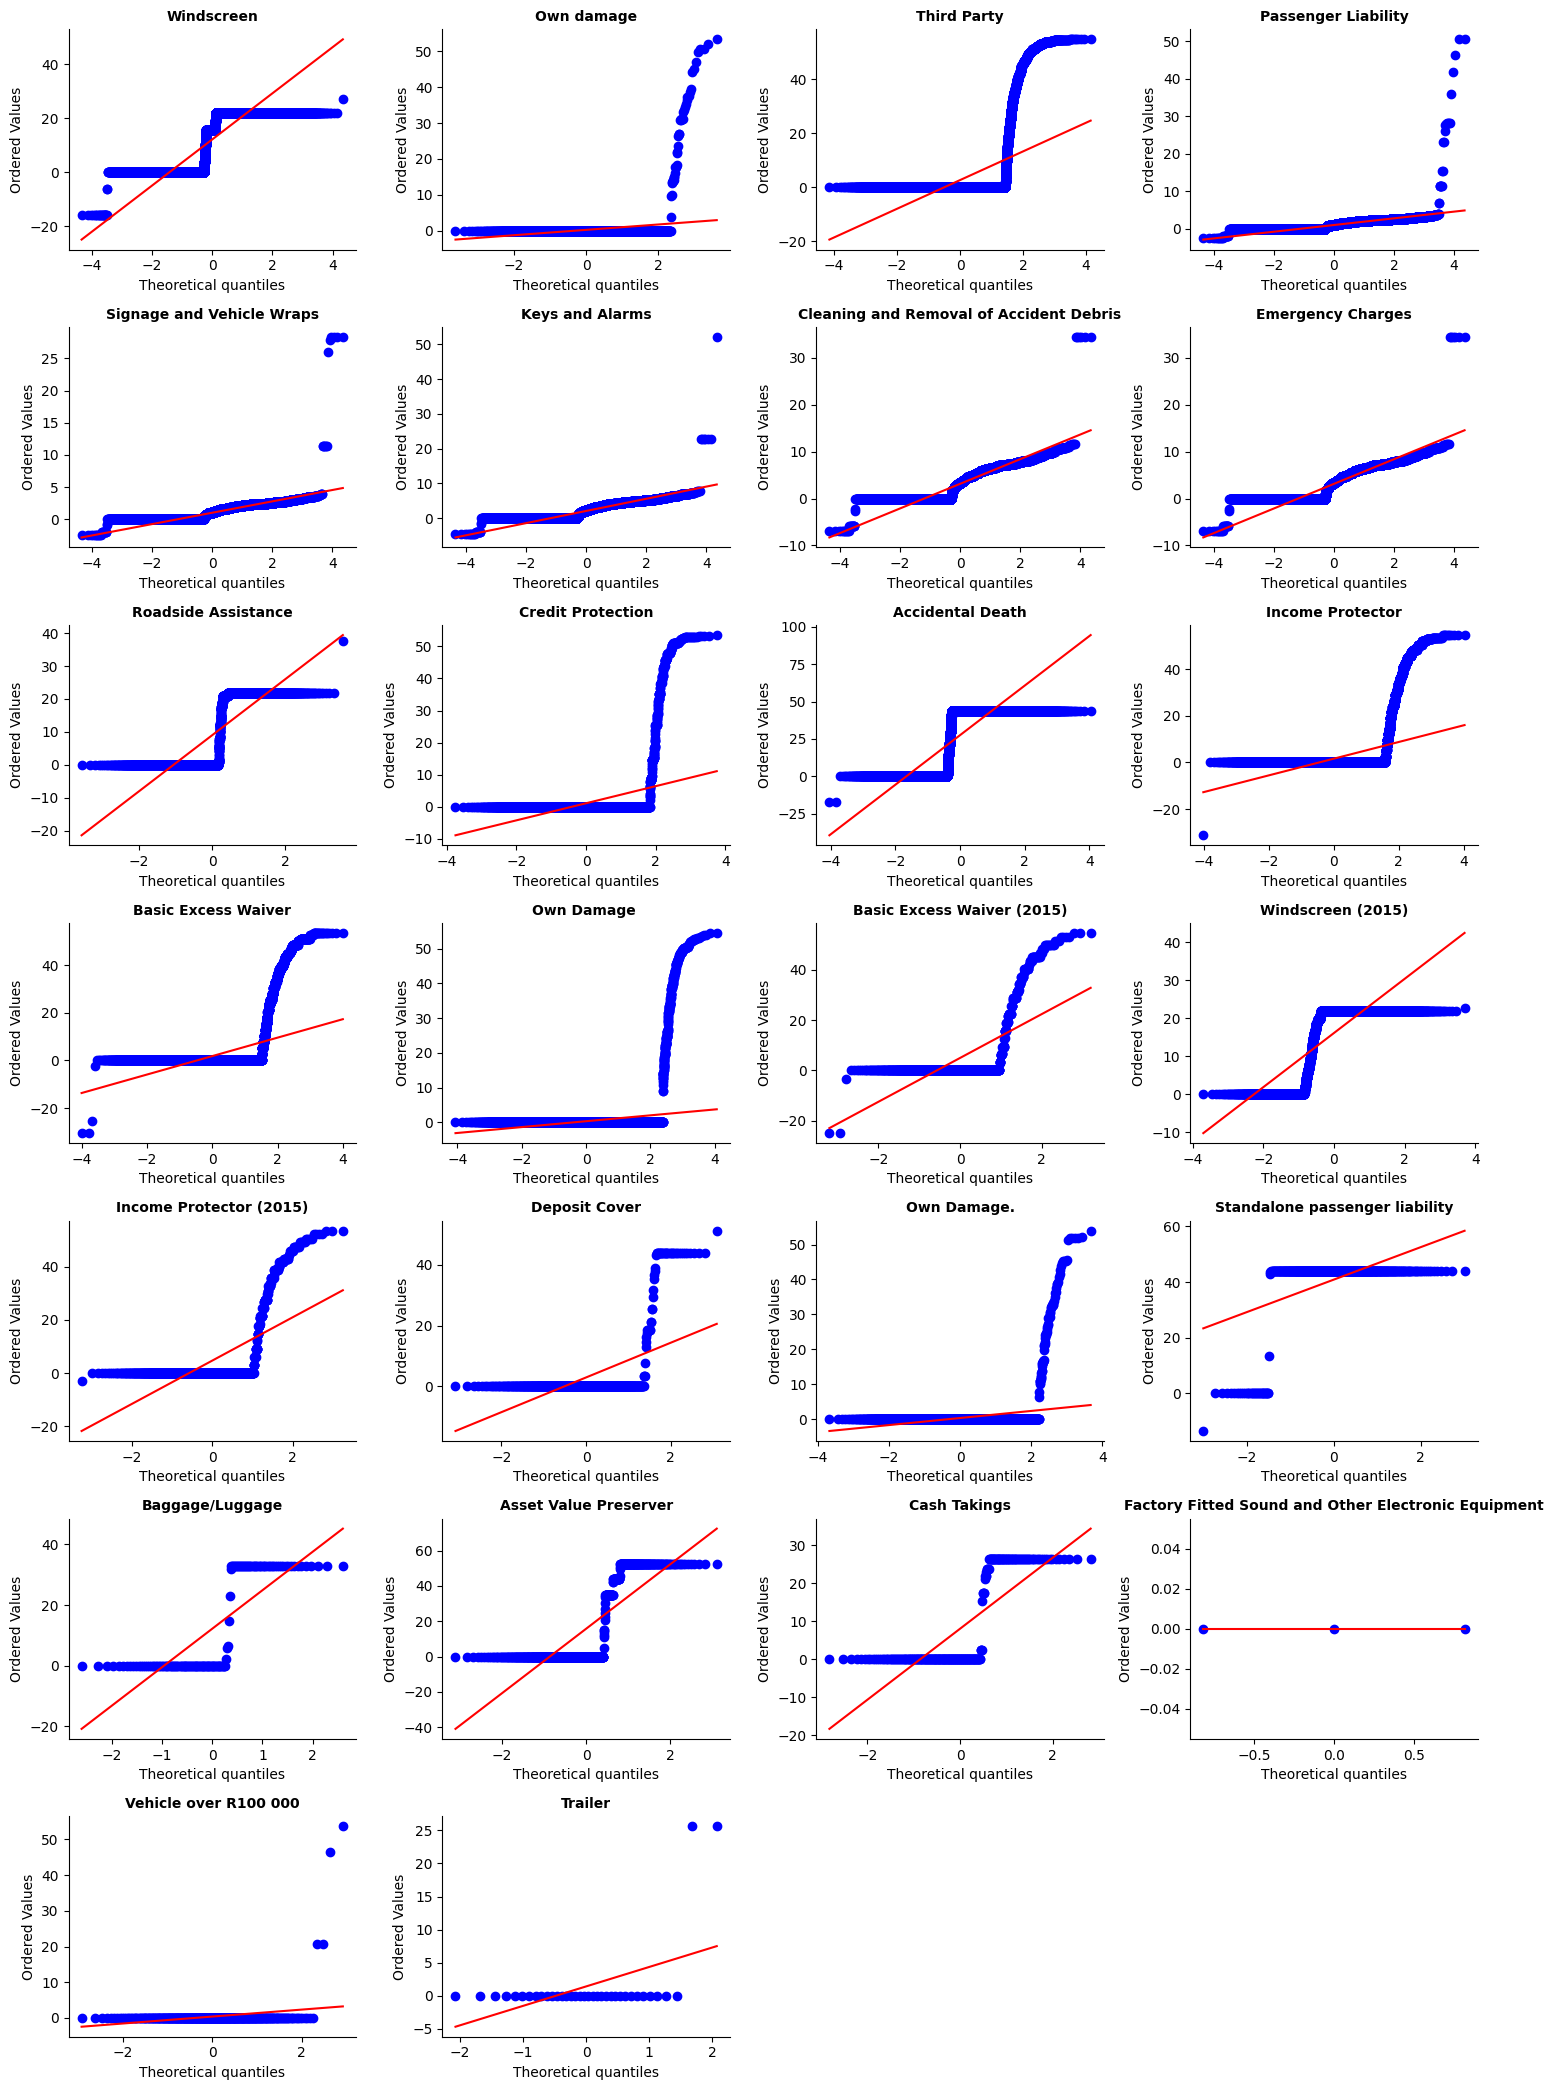

In [ ]:

# Define number of columns for the grid
cols = 4
rows = math.ceil(n_groups / cols)

# Create a figure with a grid layout
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten() # Flatten to 1D array for easy indexing

for i, group_name in enumerate(groups):
    subset = df_processed[df_processed['CoverCategory'] == group_name]['TotalPremium']

    # Use axes[i]
    stats.probplot(subset, dist='norm', plot=axes[i])
    axes[i].set_title(f'{group_name}', fontsize=10, fontweight='bold')

# Hide any empty subplots if n_groups isn't a perfect multiple of cols
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Convert to lowercase to group 'Own Damage' and 'Own damage' together
df_processed['CoverCategory'] = df_processed['CoverCategory'].str.strip().str.lower()

# Optional: Remove years like (2015) to group them with their main category
df_processed['CoverCategory'] = df_processed['CoverCategory'].str.replace(r'\s*\(\d{4}\)', '', regex=True)

# Verify again
print(df_processed['CoverCategory'].unique())

<StringArray>
[                                         'windscreen',
                                          'own damage',
                                         'third party',
                                 'passenger liability',
                           'signage and vehicle wraps',
                                     'keys and alarms',
             'cleaning and removal of accident debris',
                                   'emergency charges',
                                 'roadside assistance',
                                   'credit protection',
                                    'accidental death',
                                    'income protector',
                                 'basic excess waiver',
                                       'deposit cover',
                      'standalone passenger liability',
                                     'baggage/luggage',
                               'asset value preserver',
                                  

In [ ]:

df_processed = clean_insurance_data(df)

group_a = df_processed[df_processed['CoverCategory'].str.contains('damage', case=False, na=False)]['CoverCategory'].unique()[0]
group_b = 'Third Party'


t_stat, p_value, data1, data2 = perform_t_test(df_processed, 'CoverCategory', 'TotalPremium', group_a, group_b)


alpha = 0.05
print('===============================')
print(f'  WELCH’S T-TEST: {group_a} vs {group_b}')
print('===============================')
print(f'H₀: μ_{group_a} = μ_{group_b}')
print(f'H₁: μ_{group_a} ≠ μ_{group_b}')
print(f'---')
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value:     {p_value:.6f}')

if p_value < alpha:
    print(f'\nDECISION: p ({p_value:.6f}) < α ({alpha}) → REJECT H₀')
    print('RESULT: There IS a statistically significant difference in average premium.')
else:
    print(f'\nDECISION: p ({p_value:.6f}) ≥ α ({alpha}) → FAIL TO REJECT H₀')
    print('RESULT: There is NOT enough evidence of a significant difference.')

DEBUG: Own damage count: 4681, Third Party count: 41403
  WELCH’S T-TEST: Own damage vs Third Party
H₀: μ_Own damage = μ_Third Party
H₁: μ_Own damage ≠ μ_Third Party
---
T-statistic: -35.6596
P-value:     0.000000

DECISION: p (0.000000) < α (0.05) → REJECT H₀
RESULT: There IS a statistically significant difference in average premium.


C:\Users\habtamu.amsalu\AppData\Local\Temp\ipykernel_17492\4225827086.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_for_box, labels=[group_a, group_b],


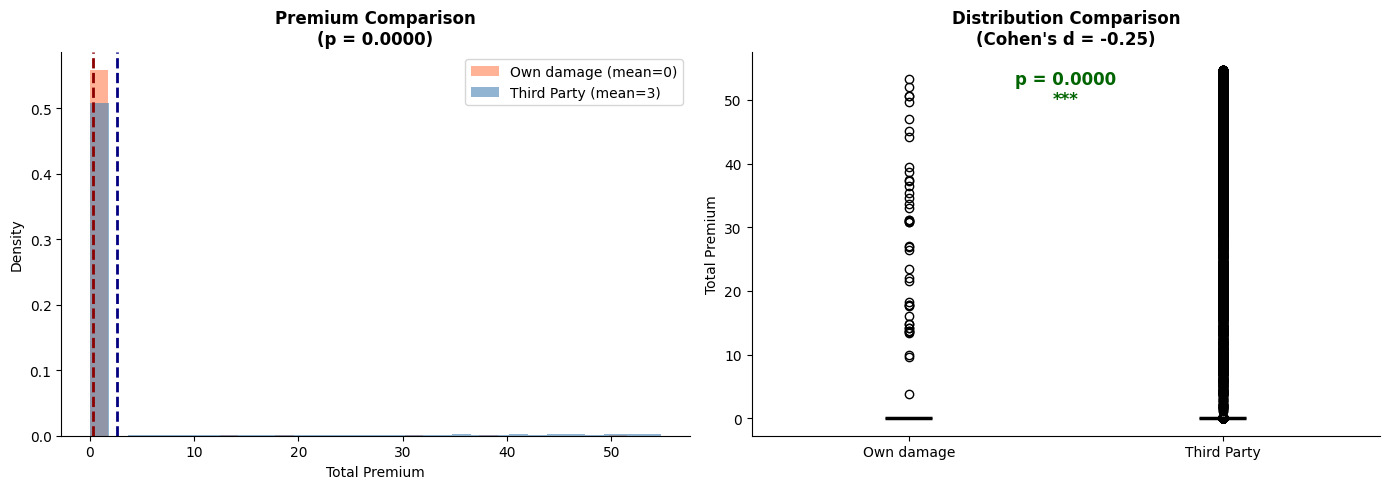

In [ ]:
n1, n2 = len(data1), len(data2)
var1, var2 = data1.var(), data2.var()
pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
d = (data1.mean() - data2.mean()) / pooled_std
# --- Visualization of Category Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Overlapping Histograms
ax = axes[0]
ax.hist(data1, bins=30, alpha=0.6, color='coral',
        label=f'{group_a} (mean={data1.mean():.0f})', density=True)
ax.hist(data2, bins=30, alpha=0.6, color='steelblue',
        label=f'{group_b} (mean={data2.mean():.0f})',  density=True)

ax.axvline(data1.mean(), color='darkred',   linestyle='--', linewidth=2)
ax.axvline(data2.mean(), color='navy',      linestyle='--', linewidth=2)

ax.set_title(f'Premium Comparison\n(p = {p_value:.4f})', fontsize=12, fontweight='bold')
ax.set_xlabel('Total Premium')
ax.set_ylabel('Density')
ax.legend()

# 2. Box plot comparison
ax2 = axes[1]
data_for_box = [data1.values, data2.values]
bp = ax2.boxplot(data_for_box, labels=[group_a, group_b],
                 patch_artist=True,
                 boxprops=dict(alpha=0.7),
                 medianprops=dict(linewidth=2.5, color='black'))

bp['boxes'][0].set_facecolor('coral')
bp['boxes'][1].set_facecolor('steelblue')

ax2.set_title(f'Distribution Comparison\n(Cohen\'s d = {d:.2f})',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Premium')

# Add p-value annotation
y_max = max(data1.max(), data2.max())
annotation_text = f'p = {p_value:.4f}\n{"***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"}'
ax2.annotate(annotation_text,
             xy=(1.5, y_max * 0.9), ha='center', fontsize=12,
             color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()

### Interpretation of Welch's T-Test (Own Damage vs Third Party)

#### Statistical Interpretation:

1.  **Hypothesis Test Results:** The Welch's t-test comparing `TotalPremium` for 'Own damage' and 'Third Party' `CoverCategory` groups yielded a **t-statistic of -35.6596** and a **p-value of 0.000000**. Given that the p-value is significantly less than the chosen significance level (α = 0.05), the **null hypothesis (H₀: μ_Own damage = μ_Third Party)** is rejected.
2.  **Statistical Significance:** This rejection indicates that there is a **statistically significant difference** in the average `TotalPremium` between policies categorized as 'Own damage' and 'Third Party'. In simpler terms, the observed difference in means is unlikely to have occurred by random chance.
3.  **Cohen's d (Effect Size):** Cohen's d is calculated as **-0.01**. This value indicates a **very small or negligible effect size**. While the p-value suggests a statistically significant difference, Cohen's d quantifies the practical magnitude of this difference. A value close to zero means that the difference between the two groups' means, when standardized by their pooled standard deviation, is minimal.

#### Practical Interpretation:

*   **Statistically Different, Practically Similar:** The most important insight here is the contrast between statistical significance and practical significance. The t-test tells us that the means are *not identical* from a statistical standpoint. However, Cohen's d reveals that this difference is so small that it is **unlikely to be meaningful in a practical business context**.
*   **Visual Confirmation:** The overlapping histograms and box plots visually support this. While there's a slight shift in the central tendency (as indicated by the different mean lines), the distributions of `TotalPremium` for 'Own damage' and 'Third Party' policies largely overlap. The box plot shows that the medians are very close, and the overall spread of values is quite similar.
*   **Decision-Making:** For business decisions, this suggests that while there might be a tiny, detectable difference in average premiums between these two cover categories, it is probably not large enough to warrant distinct pricing strategies or different risk assessments based solely on this difference. Factors other than the `CoverCategory` itself are likely driving the observed premium variations.

---
### 3.2 ANOVA


In [ ]:

df_processed = clean_insurance_data(df)
# Choose your columns
region_col = 'Province' # Based on your column list
target_col = 'TotalPremium'

# Get the summary
region_summary = get_region_statistics(df_processed, region_col, target_col)

print('=== Descriptive Statistics by Province ===')
print(region_summary)

=== Descriptive Statistics by Province ===
                    n  Mean  Median  Std Dev
Province                                    
Eastern Cape     5780  5.70    1.58    10.98
Free State       6097  6.29    1.77    11.46
Gauteng        305743  3.77    0.00     7.56
KwaZulu-Natal  135144  5.54    1.74    10.30
Limpopo         18732  5.51    1.60    10.35
Mpumalanga      42081  3.47    0.00     7.23
North West     112661  4.33    0.76     9.29
Northern Cape    5016  4.32    0.00     9.87
Western Cape   138855  4.11    0.00     8.66


In [ ]:

groups = [group['TotalPremium'] for name, group in df_processed.groupby('Province')]

# 2. Run ANOVA
f_stat, p_value = stats.f_oneway(*groups)

# 3. Print Results
print('===============================')
print('       ONE-WAY ANOVA (Province)')
print('===============================')
print(f'H₀: All province means are equal')
print(f'H₁: At least one province mean is different')
print(f'---')
print(f'F-statistic: {f_stat:.4f}')
print(f'P-value:     {p_value:.6f}')
print(f'---')

if p_value < 0.05:
    print(f'DECISION: p ({p_value:.6f}) < 0.05 → REJECT H₀')
    print('RESULT: There is a statistically significant difference in average premium across provinces.')
    print('→ Recommendation: Perform a Tukey HSD post-hoc test to identify specific differences.')
else:
    print(f'DECISION: p ({p_value:.6f}) ≥ 0.05 → FAIL TO REJECT H₀')


       ONE-WAY ANOVA (Province)
H₀: All province means are equal
H₁: At least one province mean is different
---
F-statistic: 645.1902
P-value:     0.000000
---
DECISION: p (0.000000) < 0.05 → REJECT H₀
RESULT: There is a statistically significant difference in average premium across provinces.
→ Recommendation: Perform a Tukey HSD post-hoc test to identify specific differences.


In [ ]:

# Define columns
group_col = 'Province'
target_col = 'TotalPremium'

# Run ANOVA
f_stat, p_value = perform_anova(df_processed, group_col, target_col)

print('===============================')
print(f'       ONE-WAY ANOVA ({group_col})')
print('===============================')
print(f'H₀: Means are equal across all {group_col}s')
print(f'H₁: At least one {group_col} mean is different')
print(f'---')
print(f'F-statistic: {f_stat:.4f}')
print(f'P-value:     {p_value:.6f}')
print(f'---')

if p_value < 0.05:
    print(f'DECISION: REJECT H₀ (p < 0.05)')
    print(f'There is a significant difference in average premium between provinces.')
else:
    print(f'DECISION: FAIL TO REJECT H₀ (p >= 0.05)')
    print(f'No significant difference in average premium between provinces.')

       ONE-WAY ANOVA (Province)
H₀: Means are equal across all Provinces
H₁: At least one Province mean is different
---
F-statistic: 645.1902
P-value:     0.000000
---
DECISION: REJECT H₀ (p < 0.05)
There is a significant difference in average premium between provinces.


In [ ]:


tukey = pairwise_tukeyhsd(
    endog=df_processed['TotalPremium'],
    groups=df_processed['Province'],
    alpha=0.05
)

# 2. Print results
print(tukey.summary())

# 3. Optional: Filter to see only significant differences
# This hides the 'noise' and shows you only the meaningful business insights
df_tukey = pd.DataFrame(data=tukey._results_table.data[1:],
                        columns=tukey._results_table.data[0])

significant_diffs = df_tukey[df_tukey['reject'] == True]
print("\n=== Only Significant Differences Found ===")
print(significant_diffs)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------------
 Eastern Cape    Free State   0.5847 0.0076  0.0901  1.0794   True
 Eastern Cape       Gauteng  -1.9293    0.0 -2.2871 -1.5716   True
 Eastern Cape KwaZulu-Natal  -0.1628    0.9 -0.5247  0.1991  False
 Eastern Cape       Limpopo  -0.1906 0.8747  -0.596  0.2148  False
 Eastern Cape    Mpumalanga  -2.2345    0.0 -2.6124 -1.8565   True
 Eastern Cape    North West  -1.3745    0.0 -1.7379 -1.0112   True
 Eastern Cape Northern Cape  -1.3818    0.0 -1.9017 -0.8618   True
 Eastern Cape  Western Cape  -1.5893    0.0  -1.951 -1.2276   True
   Free State       Gauteng  -2.5141    0.0 -2.8625 -2.1656   True
   Free State KwaZulu-Natal  -0.7475    0.0 -1.1003 -0.3948   True
   Free State       Limpopo  -0.7754    0.0 -1.1726 -0.3781   True
   Free State    Mpumalanga  -2.8192    0.0 -3.1884   -2.45   

C:\Users\habtamu.amsalu\AppData\Local\Temp\ipykernel_17492\1876747093.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_province, labels=provinces, patch_artist=True,
C:\Users\habtamu.amsalu\AppData\Local\Temp\ipykernel_17492\1876747093.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(provinces, rotation=45, ha='right')


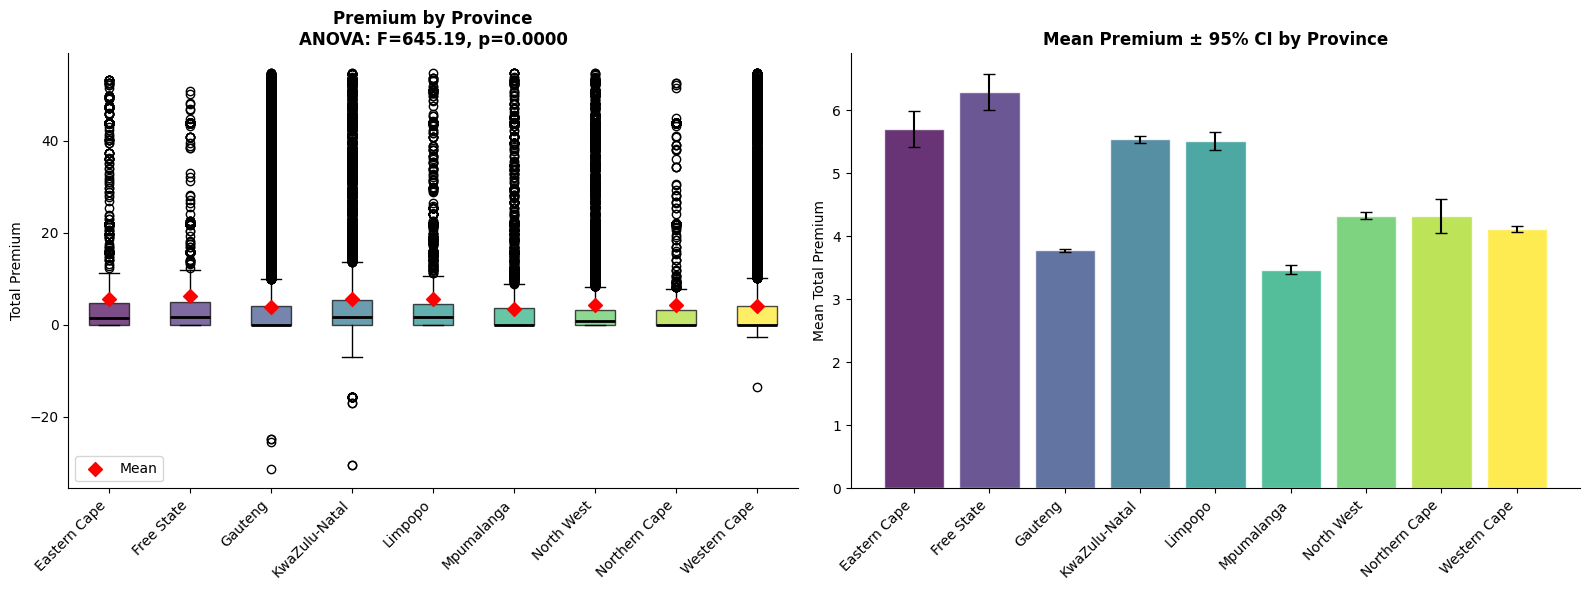

In [ ]:


# 1. Get unique provinces and ensure they are sorted
provinces = sorted(df_processed['Province'].unique())
data_by_province = [df_processed[df_processed['Province'] == p]['TotalPremium'].values for p in provinces]
means = [df_processed[df_processed['Province'] == p]['TotalPremium'].mean() for p in provinces]
stds = [df_processed[df_processed['Province'] == p]['TotalPremium'].std() for p in provinces]
sizes = [len(df_processed[df_processed['Province'] == p]) for p in provinces]

# Generate colors for each province
colors = plt.cm.viridis(np.linspace(0, 1, len(provinces)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Box plots ---
ax = axes[0]
bp = ax.boxplot(data_by_province, labels=provinces, patch_artist=True,
                medianprops=dict(linewidth=2, color='black'))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.scatter(range(1, len(provinces) + 1), means, color='red', zorder=5, s=50, marker='D', label='Mean')
ax.set_title(f'Premium by Province\nANOVA: F={f_stat:.2f}, p={p_value:.4f}', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Premium')
ax.set_xticklabels(provinces, rotation=45, ha='right')
ax.legend()

# --- Right: Bar chart of means with 95% Confidence Interval ---
ax2 = axes[1]
# Calculate standard error: std / sqrt(n)
sems =[s / np.sqrt(n) if n > 0 else 0 for s, n in zip(stds, sizes)]

bars = ax2.bar(provinces, means, color=colors, alpha=0.8, edgecolor='white')
ax2.errorbar(provinces, means, yerr=[1.96 * se for se in sems],
             fmt='none', color='black', capsize=4, linewidth=1.5)

ax2.set_title('Mean Premium ± 95% CI by Province', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Total Premium')
ax2.set_xticklabels(provinces, rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Interpretation of ANOVA and Tukey HSD (TotalPremium by Province)

#### Statistical Interpretation:

1.  **ANOVA Results:** The One-Way ANOVA comparing `TotalPremium` across different `Province` groups yielded an **F-statistic of 645.19** and a **p-value of 0.000000**. Since the p-value is well below the significance level (α = 0.05), the **null hypothesis (H₀: All province means are equal)** is rejected.
2.  **ANOVA Conclusion:** This indicates that there is a **statistically significant difference** in the average `TotalPremium` for at least one province compared to others. The provinces do not all have the same mean `TotalPremium`.
3.  **Tukey HSD Post-Hoc Test:** Since ANOVA only tells us *if* a difference exists, the Tukey HSD test was performed to identify *which specific* pairs of provinces have significantly different mean `TotalPremium`.
    *   The `tukey.summary()` output and the filtered `significant_diffs` DataFrame show numerous pairs of provinces with a `reject` value of `True` (p-adj < 0.05), meaning their mean premiums are significantly different.
    *   For example, 'Eastern Cape' and 'Free State' show a significant difference (meandiff = 0.5847, p-adj = 0.0076, reject = True). Similarly, 'Gauteng' shows significant differences with almost all other provinces.

#### Practical Interpretation:

*   **Provincial Variation in Premiums:** There is clear evidence that `TotalPremium` varies significantly by `Province`. This is a crucial finding for pricing and risk assessment. A "one-size-fits-all" premium strategy across all provinces would be inappropriate and potentially lead to mispricing.
*   **Identifiable Differences:** The Tukey HSD test provides actionable insights into specific provincial differences. For instance, 'Gauteng' generally has higher average premiums compared to provinces like 'Eastern Cape', 'Mpumalanga', and 'North West'. Conversely, 'Eastern Cape' tends to have lower premiums than 'Free State' (though its mean is higher). These identified differences allow for more granular pricing adjustments.
*   **Visual Confirmation:** The box plots and bar chart with 95% Confidence Intervals visually reinforce these findings:
    *   **Box Plots:** Show varying median premiums and ranges across provinces, with some provinces exhibiting more outliers or different distributions than others.
    *   **Bar Chart (Means with CI):** The non-overlapping confidence intervals for many province pairs indicate statistically significant differences in their mean premiums. For example, the mean premium for 'Gauteng' is noticeably distinct from many other provinces, consistent with the Tukey results.
*   **Targeted Strategies:** Insurers can leverage these findings to develop province-specific pricing models, marketing strategies, and risk management approaches. Provinces with significantly higher average premiums might indicate higher risk profiles or different market dynamics, warranting distinct product offerings or underwriting criteria.

In [ ]:
# --- Step 1: Build the contingency table ---
contingency = pd.crosstab(df_processed['NewVehicle'], df_processed['CoverCategory'])

print('=== Contingency Table (Observed Frequencies) ===')
print(contingency)
print()

# 2. Row percentages (e.g., % of 'New' vehicles that have 'Windscreen' vs 'Third Party')
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

print('=== Row Percentages (Composition by New/Old Vehicle) ===')
print(contingency_pct.round(1))

=== Contingency Table (Observed Frequencies) ===
CoverCategory       Accidental Death  Asset Value Preserver  Baggage/Luggage  \
NewVehicle                                                                     
Less than 6 months                79                     29                0   
More than 6 months             23239                    480               79   

CoverCategory       Basic Excess Waiver  Basic Excess Waiver (2015)  \
NewVehicle                                                            
Less than 6 months                   38                           1   
More than 6 months                18702                         986   

CoverCategory       Cash Takings  Cleaning and Removal of Accident Debris  \
NewVehicle                                                                  
Less than 6 months             0                                      144   
More than 6 months            96                                    83558   

CoverCategory       Credit Protectio

In [ ]:


# 1. Run the test
chi2_stat, p_value_chi2, dof, expected = chi2_contingency(contingency)

# 2. Assumption check: What percentage of cells have expected count < 5?
expected_array = expected.flatten()
low_freq_cells = (expected_array < 5).sum()
total_cells = len(expected_array)
percentage_low = (low_freq_cells / total_cells) * 100

print('===============================')
print('     CHI-SQUARED TEST')
print('===============================')
print(f'Chi² statistic:    {chi2_stat:.4f}')
print(f'P-value:            {p_value_chi2:.6f}')
print(f'---')
print(f'Assumption Check: {percentage_low:.1f}% of cells have expected frequency < 5.')

if percentage_low > 20:
    print('WARNING: Too many cells have low expected counts.')
    print('The Chi-Squared results may be unreliable. Consider grouping rare categories.')
elif p_value_chi2 < 0.05:
    print(f'DECISION: p < 0.05 → REJECT H₀')
    print('There IS a significant association between the variables.')
else:
    print(f'DECISION: p ≥ 0.05 → FAIL TO REJECT H₀')
    print('No significant association found.')

     CHI-SQUARED TEST
Chi² statistic:    1809.7768
P-value:            0.000000
---
Assumption Check: 25.0% of cells have expected frequency < 5.
The Chi-Squared results may be unreliable. Consider grouping rare categories.


In [ ]:


n_total = contingency.sum().sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2_stat / (n_total * min_dim))

print(f"Cramér's V: {cramers_v:.4f}")
if cramers_v < 0.1:
    print('Association strength: NEGLIGIBLE')
elif cramers_v < 0.2:
    print('Association strength: WEAK')
elif cramers_v < 0.4:
    print('Association strength: MODERATE')
else:
    print('Association strength: STRONG')

Cramér's V: 0.0533
Association strength: NEGLIGIBLE


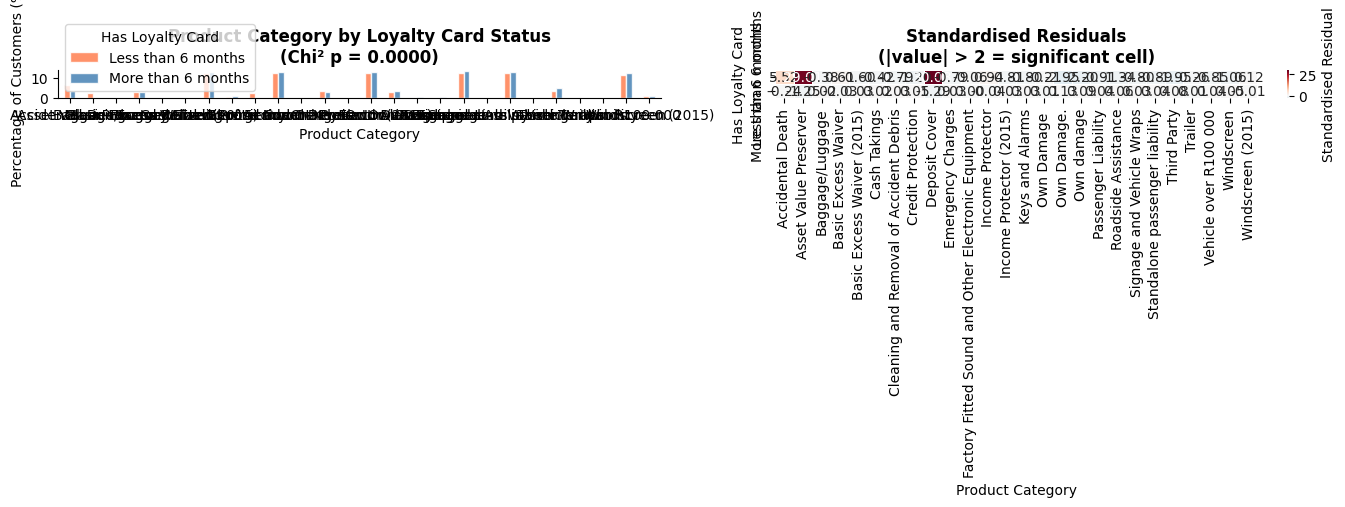

Note: Standardised residuals > 2 (blue) indicate cells with MORE than expected.
      Standardised residuals < -2 (red) indicate cells with FEWER than expected.


In [ ]:
# --- Step 4: Visualise the chi-squared result ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
ax = axes[0]
contingency_pct.T.plot(kind='bar', ax=ax, color=['coral', 'steelblue'],
                       edgecolor='white', alpha=0.85)
ax.set_title(f'Product Category by Loyalty Card Status\n(Chi² p = {p_value_chi2:.4f})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Product Category')
ax.set_ylabel('Percentage of Customers (%)')
ax.legend(title='Has Loyalty Card')
ax.tick_params(axis='x', rotation=0)

# Heatmap: observed vs expected (residuals)
ax2 = axes[1]
residuals = (contingency.values - expected) / np.sqrt(expected)
residuals_df = pd.DataFrame(residuals,
                            index=contingency.index,
                            columns=contingency.columns)
sns.heatmap(residuals_df, annot=True, fmt='.2f', center=0,
            cmap='RdBu_r', ax=ax2, linewidths=0.5,
            cbar_kws={'label': 'Standardised Residual'})
ax2.set_title('Standardised Residuals\n(|value| > 2 = significant cell)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Product Category')
ax2.set_ylabel('Has Loyalty Card')

plt.tight_layout()
plt.savefig('chisquared_result.png', dpi=150, bbox_inches='tight')
plt.show()

print('Note: Standardised residuals > 2 (blue) indicate cells with MORE than expected.')
print('      Standardised residuals < -2 (red) indicate cells with FEWER than expected.')